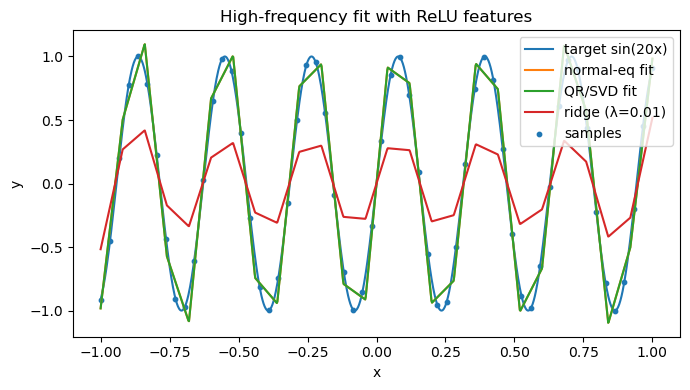

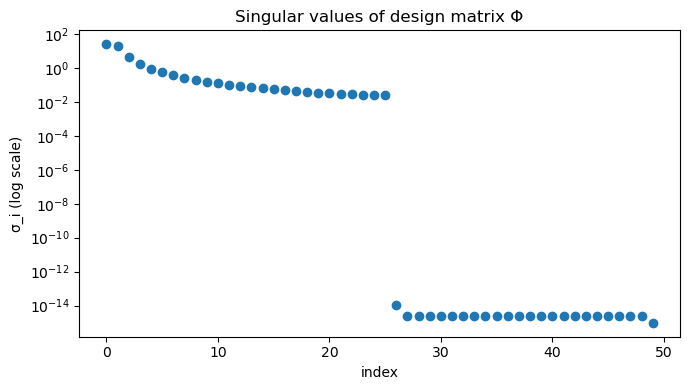


=== Diagnostics ===
#samples (M):      60
#features (p):     50
cond(Φ):           2.557e+16
min σ:             9.694e-16
max σ:             2.479e+01
MSE normal-eq:     8.270e-03
MSE QR/SVD:        8.270e-03
MSE ridge (λ=0.01): 2.195e-01


In [1]:
# High-frequency target fit with ReLU features via discrete least squares
# Requires: numpy, matplotlib, pandas (optional for the small table)

import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import lstsq, svd

rng = np.random.default_rng(0)

# ----- target: high frequency -----
def f(x, k=20):
    """Target function."""
    return np.sin(k * x)

# ----- ReLU feature map -----
def relu(z):
    return np.maximum(z, 0.0)

def design_matrix(x, n_features=50):
    """
    Build a simple ReLU feature dictionary:
      [1, x, ReLU(x-t1), ReLU(t1-x), ReLU(x-t2), ReLU(t2-x), ...]
    Knots are evenly spaced on [-1, 1).
    """
    # number of knots is half of n_features (roughly) minus bias & linear
    # you can change this design as you wish
    n_knots = max(1, n_features // 2 - 1)
    knots = np.linspace(-1, 1, n_knots + 1, endpoint=False)[1:]  # exclude -1
    Phi_list = [np.ones_like(x), x]  # bias + linear trend
    for t in knots:
        Phi_list.append(relu(x - t))
        Phi_list.append(relu(t - x))  # symmetric partner
    Phi = np.column_stack(Phi_list)
    return Phi

# ----- experiment parameters -----
M = 60                 # number of sample points (rows)
p = 50                 # feature budget (controls number of knots)
kfreq = 20             # frequency in sin(k x)
noise_std = 0.0        # set >0 to see solver blow-up with noise
ridge_lambda = 1e-2    # Tikhonov parameter

# sample points and data
x = np.linspace(-1, 1, M)
y = f(x, kfreq) + noise_std * rng.standard_normal(M)

# design matrix and SVD diagnostics
Phi = design_matrix(x, n_features=p)
U, S, Vt = svd(Phi, full_matrices=False)
cond_num = S.max() / S.min()

# assemble normal-equation pieces
ATA = Phi.T @ Phi
ATy = Phi.T @ y

# --- solvers ---

# 1) "Normal equations" (explicit solve on ATA) – numerically fragile
try:
    theta_normal = np.linalg.solve(ATA, ATy)
except np.linalg.LinAlgError:
    theta_normal = np.linalg.pinv(ATA) @ ATy  # fallback if singular

# 2) QR/SVD-based least squares (np.linalg.lstsq uses LAPACK)
theta_qr, *_ = lstsq(Phi, y, rcond=None)

# 3) Ridge / Tikhonov regularization
theta_ridge = np.linalg.solve(ATA + ridge_lambda * np.eye(ATA.shape[0]), ATy)

# predictions on a dense grid
xx = np.linspace(-1, 1, 1000)
Phi_xx = design_matrix(xx, n_features=p)
y_true = f(xx, kfreq)
y_ne = Phi_xx @ theta_normal
y_qr = Phi_xx @ theta_qr
y_ridge = Phi_xx @ theta_ridge

# simple MSE function
def mse(a, b): return float(np.mean((a - b) ** 2))

err_ne = mse(y_true, y_ne)
err_qr = mse(y_true, y_qr)
err_ridge = mse(y_true, y_ridge)

# ----- plots -----

plt.figure(figsize=(7, 4))
plt.plot(xx, y_true, label=f"target sin({kfreq}x)")
plt.plot(xx, y_ne, label="normal-eq fit")
plt.plot(xx, y_qr, label="QR/SVD fit")
plt.plot(xx, y_ridge, label=f"ridge (λ={ridge_lambda:g})")
plt.scatter(x, y, s=10, label="samples")
plt.title("High-frequency fit with ReLU features")
plt.xlabel("x"); plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.semilogy(S, marker='o', linestyle='none')
plt.title("Singular values of design matrix Φ")
plt.xlabel("index"); plt.ylabel("σ_i (log scale)")
plt.tight_layout()
plt.show()

# ----- print diagnostics -----
print("\n=== Diagnostics ===")
print(f"#samples (M):      {M}")
print(f"#features (p):     {Phi.shape[1]}")
print(f"cond(Φ):           {cond_num:.3e}")
print(f"min σ:             {S.min():.3e}")
print(f"max σ:             {S.max():.3e}")
print(f"MSE normal-eq:     {err_ne:.3e}")
print(f"MSE QR/SVD:        {err_qr:.3e}")
print(f"MSE ridge (λ={ridge_lambda:g}): {err_ridge:.3e}")

# ----- tips to explore -----
# 1) Increase M (e.g., 200) to see oversampling help.
# 2) Decrease kfreq to 3 or 5 to see conditioning improve.
# 3) Add small noise_std (e.g., 1e-3) to see normal equations break.
# 4) Tune ridge_lambda to balance bias vs variance.
# 5) Randomize knots or x (try rng.uniform(-1,1,M) for sampling).


In [ ]:

# ----- plots -----

plt.figure(figsize=(7, 4))
plt.plot(xx, y_true, label=f"target sin({kfreq}x)")
plt.plot(xx, y_ne, label="normal-eq fit")
plt.plot(xx, y_qr, label="QR/SVD fit")
plt.plot(xx, y_ridge, label=f"ridge (λ={ridge_lambda:g})")
plt.scatter(x, y, s=10, label="samples")
plt.title("High-frequency fit with ReLU features")
plt.xlabel("x"); plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.semilogy(S, marker='o', linestyle='none')
plt.title("Singular values of design matrix Φ")
plt.xlabel("index"); plt.ylabel("σ_i (log scale)")
plt.tight_layout()
plt.show()

# ----- print diagnostics -----
print("\n=== Diagnostics ===")
print(f"#samples (M):      {M}")
print(f"#features (p):     {Phi.shape[1]}")
print(f"cond(Φ):           {cond_num:.3e}")
print(f"min σ:             {S.min():.3e}")
print(f"max σ:             {S.max():.3e}")
print(f"MSE normal-eq:     {err_ne:.3e}")
print(f"MSE QR/SVD:        {err_qr:.3e}")
print(f"MSE ridge (λ={ridge_lambda:g}): {err_ridge:.3e}")

# ----- tips to explore -----
# 1) Increase M (e.g., 200) to see oversampling help.
# 2) Decrease kfreq to 3 or 5 to see conditioning improve.
# 3) Add small noise_std (e.g., 1e-3) to see normal equations break.
# 4) Tune ridge_lambda to balance bias vs variance.
# 5) Randomize knots or x (try rng.uniform(-1,1,M) for sampling).


array([-0.98261632, -0.94544739, -0.90827846, -0.87110953, -0.8339406 ,
       -0.79677167, -0.75960274, -0.72243381, -0.68526488, -0.64809595,
       -0.61092702, -0.57375809, -0.53658916, -0.49942023, -0.4622513 ,
       -0.42508237, -0.38791344, -0.35074451, -0.31357558, -0.27640665,
       -0.23923772, -0.20206879, -0.16489986, -0.12773093, -0.090562  ,
       -0.05339307, -0.01622414,  0.02094479,  0.05811372,  0.09528265,
        0.13245158,  0.16962051,  0.20678944,  0.24395837,  0.2811273 ,
        0.31829623,  0.35546516,  0.39263409,  0.42980302,  0.46697195,
        0.50325157,  0.51818785,  0.53312414,  0.54806042,  0.5629967 ,
        0.57793299,  0.59286927,  0.60780555,  0.62274184,  0.63767812,
        0.6526144 ,  0.66755069,  0.68248697,  0.69742326,  0.71235954,
        0.72729582,  0.74223211,  0.75716839,  0.77210467,  0.78704096,
        0.80197724,  0.81691352,  0.83184981,  0.84678609,  0.86172237,
        0.87665866,  0.89159494,  0.90653122,  0.92146751,  0.93